# Block-Encoded QSVT Workflow

This tutorial introduces the finite block-encoding helpers and the high-level `block_encoded_qsvt_workflow`.

Goals:

- construct an explicit dense unitary block encoding for a small matrix
- verify the top-left block and unitarity errors
- apply a QSVT polynomial to the normalized signal operator
- compare the QSVT logical block with a dense spectral polynomial reference
- run a finite QNode execution check for the same normalized signal operator

The workflow is a true finite block-encoded QSVT verification plus a simulator-scale QNode execution check. It is not a scalable oracle construction or an end-to-end quantum runtime estimate.

## Variable definitions

- $A$ is the finite input matrix and $\alpha\ge\|A\|_2$ is its block-encoding normalization.
- $B=A/\alpha$ is the normalized contraction placed in the top-left block of the encoding unitary.
- $x\in[-1,1]$ is a scalar eigenvalue of $B$, and $P(x)=1-x^2$ is the example QSVT polynomial.
- $P(A/\alpha)$ is the dense spectral reference for the logical QSVT block.
- $|\psi\rangle$ is the normalized input state used by the finite QNode execution.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

from qsvt.algorithms import block_encoded_qsvt_workflow
from qsvt.block_encoding import (
    block_encode_matrix,
    extract_block_encoded_operator,
    verify_block_encoding,
)
from qsvt.pde import dirichlet_laplacian_1d
from qsvt.qsvt import execute_qsvt_circuit
from qsvt.polynomials import eval_polynomial
from qsvt.reports import report_to_jsonable
from qsvt.spectral import eigh_hermitian

np.set_printoptions(precision=4, suppress=True)

## Build A Finite Block Encoding

The block-encoding helper uses a dense unitary dilation. For a normalized contraction `B = A / alpha`, the top-left block of the unitary is exactly `B` up to numerical precision.

In [2]:
matrix = np.array(
    [
        [2.0, 0.35, 0.0],
        [0.35, 1.4, 0.2],
        [0.0, 0.2, 0.8],
    ],
    dtype=float,
)

encoding = block_encode_matrix(matrix)
verification = verify_block_encoding(encoding)
reconstructed = extract_block_encoded_operator(
    encoding.unitary,
    encoding.logical_dimension,
    alpha=encoding.alpha,
)

print("alpha:", encoding.alpha)
print("logical_dimension:", encoding.logical_dimension)
print("unitary_dimension:", encoding.unitary_dimension)
print("block_error:", verification["block_error"])
print("unitarity_error:", verification["unitarity_error"])
print("reconstruction_error:", np.linalg.norm(reconstructed - matrix))

alpha: 2.166226041207235
logical_dimension: 3
unitary_dimension: 6
block_error: 0.0
unitarity_error: 1.275387486109542e-15
reconstruction_error: 0.0


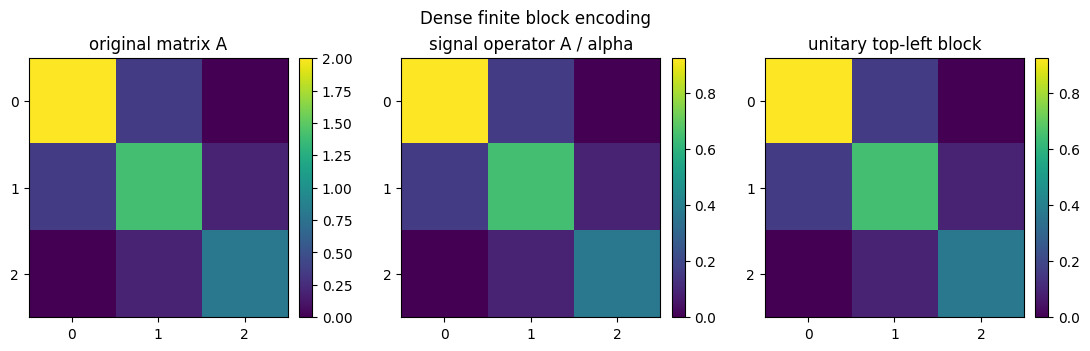

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), constrained_layout=True)

for ax, data, title in [
    (axes[0], matrix, "original matrix A"),
    (axes[1], encoding.signal_operator, "signal operator A / alpha"),
    (axes[2], encoding.top_left_block(), "unitary top-left block"),
]:
    image = ax.imshow(np.real_if_close(data), cmap="viridis")
    ax.set_title(title)
    ax.set_xticks(range(data.shape[1]))
    ax.set_yticks(range(data.shape[0]))
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Dense finite block encoding")
plt.show()

## Apply A QSVT Polynomial

The workflow below applies `P(x) = 1 - x^2` to a positive finite-difference Laplacian after normalization. The existing workflow compares a PennyLane QSVT logical block with the dense spectral reference `P(A / alpha)`. The following section then runs the same normalized signal operator through a QNode execution path.

In [4]:
grid, laplacian = dirichlet_laplacian_1d(6)
state = np.sin(np.pi * grid) + 0.25 * np.sin(5.0 * np.pi * grid)
coeffs = np.array([1.0, 0.0, -1.0])

result = block_encoded_qsvt_workflow(laplacian, coeffs, state=state)
report = report_to_jsonable(result.as_report())

signal_evals, _ = eigh_hermitian(result.block_encoding.signal_operator)
filter_values = eval_polynomial(coeffs, signal_evals)

print("workflow:", report["mode"])
print("pennylane_qsvt_check:", report["truth_contract"]["pennylane_qsvt_check"])
print("operator_relative_error:", result.operator_relative_error)
print("state_relative_error:", result.state_relative_error)

workflow: block-encoded-qsvt-workflow
pennylane_qsvt_check: succeeded
operator_relative_error: 1.000085679496161e-12
state_relative_error: 1.0000638768158241e-12


## Execute The Finite QSVT Circuit

The block workflow above validates the logical operator. Here we run `execute_qsvt_circuit` on the normalized signal operator with a normalized input state. This queues `qml.qsvt` inside a PennyLane QNode and records circuit resource metadata instead of extracting the full unitary with `qml.matrix`.

In [5]:
normalized_state = state / np.linalg.norm(state)

qnode_execution = execute_qsvt_circuit(
    result.block_encoding.signal_operator,
    coeffs,
    normalized_state,
)

qnode_output = qnode_execution.logical_output
qnode_reference = result.reference_operator @ normalized_state
qnode_real_error = np.linalg.norm(np.real(qnode_output) - qnode_reference)
qnode_max_imag = np.max(np.abs(np.imag(qnode_output)))

print("execution_kind:", qnode_execution.execution_kind)
print("gate_types:", qnode_execution.resource_summary["gate_types"])
print(f"logical_success_probability: {qnode_execution.logical_success_probability:.12f}")
print(f"qnode_real_error: {qnode_real_error:.3e}")
print(f"qnode_max_imag: {qnode_max_imag:.3e}")

execution_kind: pennylane-qnode-statevector-qsvt-execution
gate_types: {'StatePrep': 1, 'QSVT': 1}
logical_success_probability: 0.967454109399
qnode_real_error: 9.771e-13
qnode_max_imag: 5.830e-02


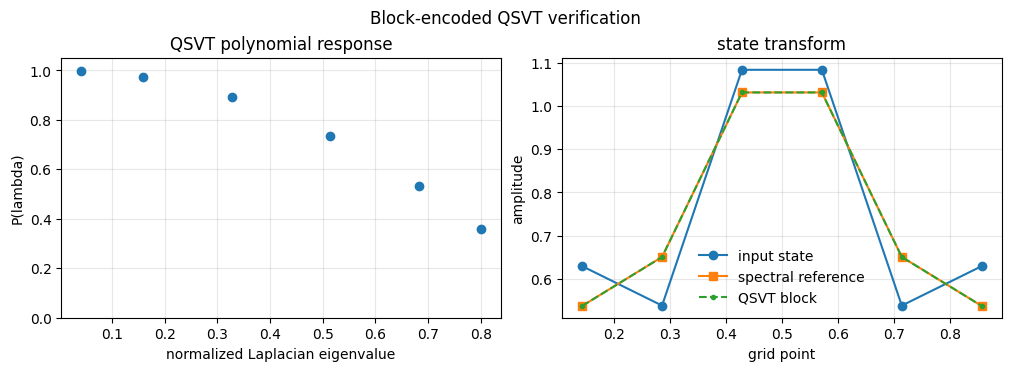

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), constrained_layout=True)

axes[0].plot(signal_evals, filter_values, "o")
axes[0].set_xlabel("normalized Laplacian eigenvalue")
axes[0].set_ylabel("P(lambda)")
axes[0].set_title("QSVT polynomial response")
axes[0].set_ylim(0.0, 1.05)
axes[0].grid(alpha=0.3)

axes[1].plot(grid, state, "o-", label="input state")
axes[1].plot(
    grid, np.real_if_close(result.reference_state), "s-", label="spectral reference"
)
axes[1].plot(grid, np.real_if_close(result.qsvt_state), ".--", label="QSVT block")
axes[1].set_xlabel("grid point")
axes[1].set_ylabel("amplitude")
axes[1].set_title("state transform")
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.3)

fig.suptitle("Block-encoded QSVT verification")
plt.show()

## Validation

These checks keep the tutorial aligned with the package contract: the finite block encoding is valid, and the QSVT block agrees with the spectral polynomial reference for this positive Hermitian signal.

In [7]:
assert verification["block_encoding_verified"] is True
assert verification["unitary_verified"] is True
assert np.linalg.norm(reconstructed - matrix) < 1e-10
assert result.operator_relative_error is not None
assert result.operator_relative_error < 1e-9
assert result.state_relative_error is not None
assert result.state_relative_error < 1e-9

assert qnode_execution.execution_kind == "pennylane-qnode-statevector-qsvt-execution"
assert qnode_execution.resource_summary["gate_types"]["QSVT"] == 1
assert qnode_real_error < 1e-10

print("validation: passed")

validation: passed
